# 14. Convolutional LSTM Regression Kriging


**Dataset:** California PM2.5 monitoring network, 2025 (`data/CA_pm25_2025.csv`)

**Prediction grid:** Classical space-time Ordinary Kriging reference (`data/CA_pm25_grid_predictions.csv`)

**Target:** Monthly mean PM2.5 (µg/m³)

**Library:** `pygstat` v0.1.0 — `ConvLSTM`, `CNNLSTMRegressionKriging`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the California PM2.5 Panel](#4-load-and-explore-the-california-pm25-panel)
5. [Rasterize the Sensor Network](#5-rasterize-the-sensor-network)
6. [Hold-Out Station Split](#6-hold-out-station-split)
7. [Fit ConvLSTM Regression Kriging](#7-fit-convlstm-regression-kriging)
8. [Training Curves](#8-training-curves)
9. [Validate on Held-Out Stations](#9-validate-on-held-out-stations)
10. [Residual Variograms](#10-residual-variograms)
11. [Predict on the California Grid](#11-predict-on-the-california-grid)
12. [Compare with Classical ST Kriging](#12-compare-with-classical-st-kriging)
13. [Map Predictions](#13-map-predictions)
14. [CPU vs GPU ConvLSTM Timing](#14-cpu-vs-gpu-convlstm-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)



***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** with **ordinary kriging of the residuals**. At location $\mathbf{s}$ and time $t$,

$$
Z(\mathbf{s}, t) = \hat{m}(\mathbf{s}, t) + \hat{e}(\mathbf{s}, t)
$$

where $\hat{m}(\mathbf{s}, t)$ is the trend prediction and $\hat{e}(\mathbf{s}, t)$ is the kriged residual. Tutorials 7.1–7.5 use spatial covariates (and, for GNNs, a $k$-NN graph of sample locations) for a *purely spatial* trend. This notebook uses a **Convolutional LSTM** (Shi et al., 2015) as a *spatio-temporal* trend: the monitoring network at each month is rasterized onto a small regular image, a ConvLSTM processes that image sequence, and predictions at arbitrary coordinates are read back with bilinear interpolation. Residuals of that trend are then kriged independently per month — the same RK recipe as `pygstat.kriging_STGNN` and `pygstat.kriging_STGTN`, but with a **raster/CNN** backbone instead of a graph.

This is the raster counterpart of those graph modules, and it uses the same California PM2.5 panel as [Tutorial 13 (Spatio-Temporal Kriging)](13_krigingST.ipynb). The validation protocol matches `tests/test_kriging_CNNLSTM.py` exactly (same seed, same 25 held-out stations, same classical ST-kriging grid as the reference surface).

| Step | What we do |
|------|------------|
| Data | Load daily CA PM2.5 for 2025 (163 stations); aggregate to monthly means; project to California Albers (EPSG:3310, meters) |
| Raster | Rasterize stations onto a 32-cell (longer-axis) image with two channels: value and observation mask |
| Split | Hold out **25 complete stations** entirely (seed=0), matching `pygstat.krigeST` and the ConvLSTM unit tests |
| Fit | Fit `ConvLSTM` (`grid_size=32`, `hidden_channels=16`, 2 layers) on the remaining stations, with per-month residual ordinary kriging |
| Validation | Predict every held-out station-month; report RMSE, MAE, $R^2$ vs a naive-mean baseline |
| Grid | Predict at the 5 km California grid used by classical ST kriging; correlate month-by-month with `CA_pm25_grid_predictions.csv` |
| Mapping | Draw monthly PM2.5 surfaces, kriging standard error, and a side-by-side comparison with the classical reference |
| CPU / GPU | Time `ConvLSTM.fit`+`predict` on CPU vs GPU using **sgsim** CA-like PM2.5 ($n=8{,}400$) |

By the end you will have a validated ConvLSTM interpolator, a monthly PM2.5 surface for California in 2025, and a CPU vs GPU timing of ConvLSTM training+inference on an SGS-simulated panel.

### ConvLSTM vs. graph ST models in this library

`pygstat` wraps three families of spatio-temporal *trend + residual kriging* models. Each follows the same RK recipe; they differ in how the trend sees the monitoring network.

| Class | Architecture | How space is represented |
|-------|--------------|-------------------------|
| `TGCN` / `DCRNN` (`kriging_STGNN`) | Recurrent GNN | $k$-NN graph; message passing |
| `STTN` / `GMAN` (`kriging_STGTN`) | Graph Transformer | $k$-NN graph; spatial/temporal attention |
| `ConvLSTM` (`kriging_CNNLSTM`) | Convolutional LSTM | Regular image; 2-D convolutions + bilinear sampling |

`ConvLSTM` is a plain alias of `CNNLSTMRegressionKriging` (there is only one architecture in this module). Graphs preserve exact station topology; the raster pays a resolution cost (a sparse 163-station network is painted onto a coarse image) in exchange for translationally invariant local filters — the inductive bias a CNN encodes.



***
## 2. Mathematical Formulation

The target $Z(\mathbf{s}, t)$ at location $\mathbf{s}$ and time $t$ is

$$
Z(\mathbf{s}, t) = \mu(\mathbf{s}, t) + \varepsilon(\mathbf{s}, t)
$$

where $\mu(\mathbf{s}, t)$ is a **deterministic spatio-temporal trend** (the ConvLSTM) and $\varepsilon(\mathbf{s}, t)$ is a **zero-mean, spatially autocorrelated residual**, kriged independently at each time step.

### 2.1 Rasterization

Given $n$ stations with coordinates $\mathbf{s}_i = (x_i, y_i)$ and a panel $Z \in \mathbb{R}^{n \times T}$ (NaN allowed), the training bounding box is padded by 5% and split into an $H \times W$ lattice so the *longer* axis gets `grid_size` cells and the shorter axis keeps the study-area aspect ratio (California is tall, so $H > W$). Each station maps to a nearest pixel; stations that share a pixel are mean-aggregated. The ConvLSTM input at time $t$ is a two-channel image

$$
X_t \in \mathbb{R}^{2 \times H \times W}, \qquad
X_t^{(0)} = \text{masked mean value},\quad
X_t^{(1)} = \text{observation mask } \in \{0,1\}.
$$

A station's true location rarely sits on a pixel center, so predictions are **not** snapped to the nearest cell. They are read off the output image with bilinear interpolation (`torch.nn.functional.grid_sample`) at the continuous coordinate of each query point.

### 2.2 Convolutional LSTM (Shi et al., 2015)

A plain LSTM replaces every gate's fully-connected transform with a 2-D convolution over the concatenated input and previous hidden state. For input $X_t$, hidden state $H_{t-1}$, and cell state $C_{t-1}$,

$$
\begin{aligned}
i_t &= \sigma(W_{xi} * X_t + W_{hi} * H_{t-1} + b_i), \\
f_t &= \sigma(W_{xf} * X_t + W_{hf} * H_{t-1} + b_f), \\
o_t &= \sigma(W_{xo} * X_t + W_{ho} * H_{t-1} + b_o), \\
g_t &= \tanh(W_{xg} * X_t + W_{hg} * H_{t-1} + b_g), \\
C_t &= f_t \odot C_{t-1} + i_t \odot g_t, \\
H_t &= o_t \odot \tanh(C_t),
\end{aligned}
$$

where $*$ is convolution and $\odot$ is the Hadamard product. In the implementation, the four input-to-state and state-to-state convolutions are fused into a single `Conv2d` over $[X_t, H_{t-1}]$ and split into four chunks. Stacking $L$ such cells and applying a shared $1 \times 1$ convolution to the top hidden state produces an output image $\hat{M}_t \in \mathbb{R}^{1 \times H \times W}$ at every month. The trend at a query point $\mathbf{s}_0$ is the bilinear sample of $\hat{M}_t$ at $\mathbf{s}_0$.

### 2.3 IGNNK-style random masking

Training follows the inductive masked-reconstruction protocol of Wu, Cui, Nie & Wang (2021), shared with `kriging_STGNN` / `kriging_STGTN`. Each epoch:

1. A validation subset of stations is **fully excluded** from the raster (they never appear as input *or* as reconstruction targets for the training loss).
2. A random fraction `mask_ratio` of the remaining observed (station, month) cells is also hidden.
3. The network reconstructs each hidden station's *own* value via bilinear sampling at its exact coordinate — not the blocky average of its containing pixel.

That forces the ConvLSTM to interpolate from the surrounding image rather than copy a pixel it already saw.

### 2.4 Residual kriging

After the network is trained, honest out-of-fold reconstructions (stations left out of the raster, then sampled at their exact coordinates) yield residuals $e_i(t) = Z(\mathbf{s}_i, t) - \hat{m}(\mathbf{s}_i, t)$. A spherical variogram is fit independently at each month $t$ that has enough observations, and ordinary kriging of those residuals is added back:

$$
\hat{Z}(\mathbf{s}_0, t) = \hat{m}(\mathbf{s}_0, t) + \sum_{i \in \mathcal{O}_t} \lambda_i(t)\, e_i(t).
$$

Set `krige_residuals=False` to skip this step (the prediction is then the ConvLSTM trend alone, and `return_std=True` returns zeros).


***
## 3. Python Setup

`ConvLSTM(..., device=...)` (and the other PyTorch ST models) send the network to:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | CUDA when this PyTorch build has kernels for the attached GPU. Falls back to CPU otherwise. |
| `'cuda'` | Force GPU. |
| `'cpu'` | Always CPU. |

This notebook probes CUDA once and stores the result in `DEVICE`. Fits below pass `device=DEVICE`. **§14** times `device='cpu'` against `device='cuda'` on an **SGS-simulated** CA-like PM2.5 panel with $n > 5{,}000$ space-time observations. Residual ordinary kriging is skipped in that section (`krige_residuals=False`) so the times isolate the neural net, not the CPU-only kriging solve.

Install extras with `pip install pygstat[pytorch]`.


In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

# pygstat optionally imports TensorFlow for DeepRegressionKrigingTF.
# Loading that stack in the same process as PyTorch can crash; keep TF out.
sys.modules.setdefault("tensorflow", None)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pygstat import ConvLSTM, CNNLSTMRegressionKriging, load_ca_pm25_panel, sgsim
from pygstat.kriging_CNNLSTM import (
    ConvLSTMCell,
    _cell_index,
    _make_grid_shape,
    _rasterize,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

DATA_DIR = Path("..") / "data"
MONTH_NAMES = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

print("torch version :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cpu"
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    print("GPU           :", torch.cuda.get_device_name(0), f"(sm_{major}{minor})")
    # This wheel ships kernels for sm_75+; older cards fall back to CPU.
    if (major, minor) >= (7, 5):
        DEVICE = "cuda"
    else:
        print("GPU compute capability is below sm_75; using CPU")
print("Using device :", DEVICE)


torch version : 2.14.0+cu126
CUDA available: True
GPU           : NVIDIA GeForce RTX 2080 Ti (sm_75)
Using device : cuda



***
## 4. Load and Explore the California PM2.5 Panel

`data/CA_pm25_2025.csv` holds daily PM2.5 (µg/m³) at 163 California air-quality stations through 2025 (`Site ID`, `Lat`, `Long`, `Date`, `Daily_PM2.5_ug_m3`). `load_ca_pm25_panel` aggregates daily readings to **monthly station means** and projects coordinates from lat/long (EPSG:4326) to **California Albers Equal Area (EPSG:3310, meters)**, so spatial distances in residual kriging are in a metric unit.

The companion file `data/CA_pm25_grid_predictions.csv` is the classical space-time Ordinary Kriging surface for the same panel (`scripts/predict_ca_pm25_grid.py` via `pygstat.krigeST`) — the reference this tutorial compares against, and the same file used by `tests/test_kriging_CNNLSTM.py`.


In [2]:
raw = pd.read_csv(DATA_DIR / "CA_pm25_2025.csv")
print(f"Daily file : {raw.shape[0]:,} rows, {raw['Site ID'].nunique()} stations")
print(f"Date range : {raw['Date'].min()} -> {raw['Date'].max()}")
print("Columns    :", list(raw.columns))
raw.head()


Daily file : 59,566 rows, 163 stations
Date range : 01/01/2025 -> 12/31/2025
Columns    : ['Site ID', 'State', 'County', 'Lat', 'Long', 'Date', 'Daily_PM2.5_ug_m3', 'Daily_AQI']


,Site ID,State,County,Lat,Long,Date,Daily_PM2.5_ug_m3,Daily_AQI
0,60010009,California,Alameda,37.743,-122.170,01/01/2025,12.200,57
1,60010009,California,Alameda,37.743,-122.170,01/02/2025,9.200,51
2,60010009,California,Alameda,37.743,-122.170,01/03/2025,7.700,43
3,60010009,California,Alameda,37.743,-122.170,01/04/2025,5.800,32
4,60010009,California,Alameda,37.743,-122.170,01/05/2025,6.700,37


In [3]:
panel = load_ca_pm25_panel(DATA_DIR / "CA_pm25_2025.csv")
wide = panel.pivot(index="site_id", columns="month", values="pm25").sort_index()
coords = (
    panel[["site_id", "x", "y"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index][["x", "y"]].to_numpy()
)
values = wide.to_numpy()  # (163, 12); NaN allowed
site_ids = wide.index.to_numpy()
latlon = (
    panel[["site_id", "lat", "lon"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index]
)

n_missing = int(np.isnan(values).sum())
counts = (~np.isnan(values)).sum(axis=1)
complete = np.flatnonzero(counts == 12)

print(f"Monthly panel : {len(panel):,} site-month rows")
print(f"Stations      : {len(coords)}  (coords {coords.shape}, values {values.shape})")
print(f"Complete 12-mo: {len(complete)} / {len(coords)}")
print(f"Missing cells  : {n_missing} station-months (NaN)")
print(
    f"PM2.5 (µg/m³) : mean={np.nanmean(values):.2f}  "
    f"min={np.nanmin(values):.2f}  max={np.nanmax(values):.2f}"
)
print(f"Albers x      : {coords[:, 0].min():.0f} .. {coords[:, 0].max():.0f} m")
print(f"Albers y      : {coords[:, 1].min():.0f} .. {coords[:, 1].max():.0f} m")
panel.head()


Monthly panel : 1,935 site-month rows
Stations      : 163  (coords (163, 2), values (163, 12))
Complete 12-mo: 156 / 163
Missing cells  : 21 station-months (NaN)
PM2.5 (µg/m³) : mean=7.01  min=-0.50  max=39.05
Albers x      : -352817 .. 424125 m
Albers y      : -602223 .. 423150 m


,site_id,month,pm25,lat,lon,x,y
0,60010009,0,6.948,37.743,-122.170,-190936.009,-28196.821
1,60010009,1,3.736,37.743,-122.170,-190936.009,-28196.821
2,60010009,2,3.681,37.743,-122.170,-190936.009,-28196.821
3,60010009,3,5.323,37.743,-122.170,-190936.009,-28196.821
4,60010009,4,6.922,37.743,-122.170,-190936.009,-28196.821


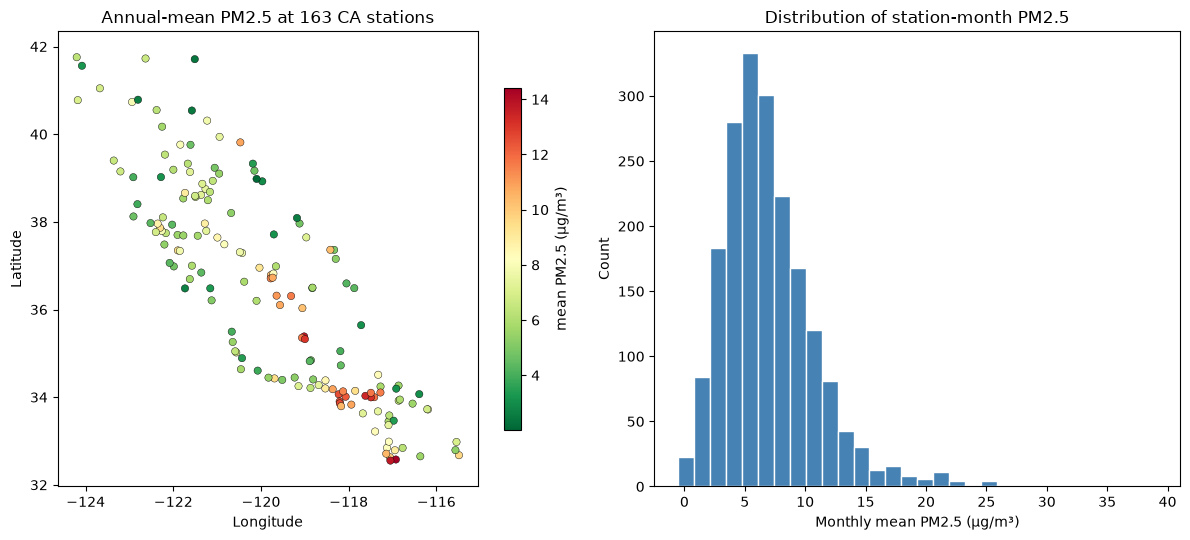

In [4]:
mean_pm = np.nanmean(values, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

sc = axes[0].scatter(
    latlon["lon"], latlon["lat"], c=mean_pm,
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3,
)
plt.colorbar(sc, ax=axes[0], label="mean PM2.5 (µg/m³)", shrink=0.75)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Annual-mean PM2.5 at 163 CA stations")
axes[0].set_aspect("equal", adjustable="datalim")

axes[1].hist(values[~np.isnan(values)], bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Monthly mean PM2.5 (µg/m³)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of station-month PM2.5")
plt.tight_layout()
plt.show()


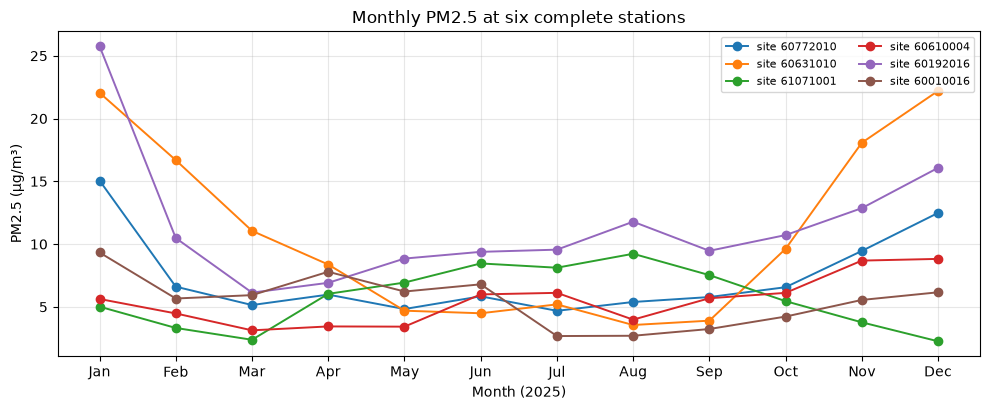

In [5]:
# Six example station series (shared winter peak, station-to-station amplitude)
rng_plot = np.random.default_rng(1)
demo_idx = rng_plot.choice(complete, size=6, replace=False)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i in demo_idx:
    ax.plot(range(12), values[i], marker="o", linewidth=1.4, label=f"site {int(site_ids[i])}")
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_xlabel("Month (2025)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Monthly PM2.5 at six complete stations")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Annual-mean PM2.5 is highest in the Central Valley and the South Coast and lowest along the north coast and Sierra. The six example series show a shared seasonal pattern (higher in winter) plus station-to-station differences — the two ingredients a ConvLSTM has to capture from a coarse raster of the network.



***
## 5. Rasterize the Sensor Network

Before fitting, look at the image the ConvLSTM actually sees. `_make_grid_shape` preserves California's N–S elongation: the longer axis gets `grid_size=32` cells and the shorter axis is scaled by the aspect ratio. Each month becomes a 2-channel image (value + mask). Most pixels are empty — 163 stations painted onto a ~32 × ~12 lattice is a sparse "image", which is why bilinear sampling at exact coordinates matters, and why grid-level correlation with classical ST kriging is typically a bit below the graph-based models.


Bounding box  : x=[-391664, 462972], y=[-653491, 474419] m
Raster shape  : H=32, W=24  (T, C, H, W) = (12, 2, 32, 24)
Occupied cells: 108 / 768  (14.1%)
Stations/cell : max=4


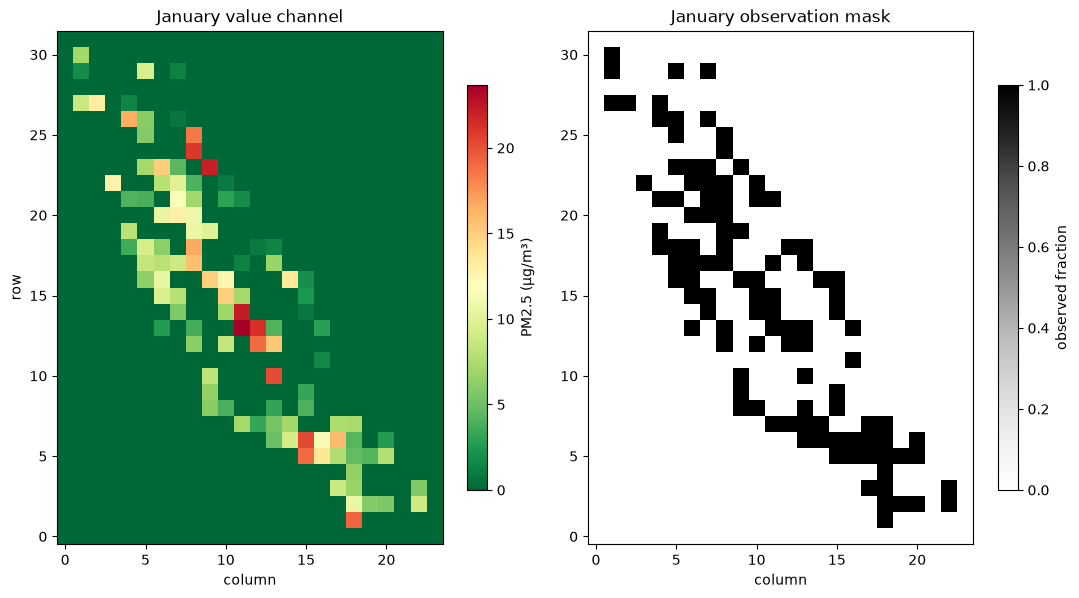

In [6]:
margin = 0.05
xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
pad_x = max((xmax - xmin) * margin, 1e-6)
pad_y = max((ymax - ymin) * margin, 1e-6)
bbox = (xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y)
H, W = _make_grid_shape(bbox, grid_size=32)
cell_idx = _cell_index(coords, bbox, H, W)

obs_mask = ~np.isnan(values)
values_filled = np.nan_to_num(values, nan=0.0)
img = _rasterize(values_filled.astype(np.float32), obs_mask, cell_idx, H, W)
n_occupied = int((img[:, 1] > 0).reshape(12, -1).any(axis=0).sum())

print(f"Bounding box  : x=[{bbox[0]:.0f}, {bbox[1]:.0f}], y=[{bbox[2]:.0f}, {bbox[3]:.0f}] m")
print(f"Raster shape  : H={H}, W={W}  (T, C, H, W) = {img.shape}")
print(f"Occupied cells: {n_occupied} / {H * W}  ({100 * n_occupied / (H * W):.1f}%)")
print(f"Stations/cell : max={(np.bincount(cell_idx, minlength=H * W).max())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 6.2))
im0 = axes[0].imshow(img[0, 0], origin="lower", cmap="RdYlGn_r", aspect="equal")
axes[0].set_title("January value channel")
axes[0].set_xlabel("column")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], shrink=0.7, label="PM2.5 (µg/m³)")

im1 = axes[1].imshow(img[0, 1], origin="lower", cmap="Greys", vmin=0, vmax=1, aspect="equal")
axes[1].set_title("January observation mask")
axes[1].set_xlabel("column")
plt.colorbar(im1, ax=axes[1], shrink=0.7, label="observed fraction")
plt.tight_layout()
plt.show()


In [7]:
# ConvLSTMCell: one time step, 2 input channels (value + mask) -> hidden feature map
cell = ConvLSTMCell(in_channels=2, hidden_channels=16, kernel_size=3)
x = torch.randn(1, 2, H, W)
h = torch.zeros(1, 16, H, W)
c = torch.zeros(1, 16, H, W)
h_new, c_new = cell(x, h, c)
print(f"ConvLSTMCell input  x: {tuple(x.shape)}")
print(f"ConvLSTMCell hidden h: {tuple(h_new.shape)}")
print(f"ConvLSTMCell cell   c: {tuple(c_new.shape)}")
print(f"Finite hidden state  : {bool(torch.isfinite(h_new).all())}")


ConvLSTMCell input  x: (1, 2, 32, 24)
ConvLSTMCell hidden h: (1, 16, 32, 24)
ConvLSTMCell cell   c: (1, 16, 32, 24)
Finite hidden state  : True



***
## 6. Hold-Out Station Split

To test genuine spatial-temporal *extrapolation* (not just interpolating a missing month at a known site), we hold out **25 stations with complete 12-month coverage** entirely. Every month at those sites is predicted from the remaining 138 stations. The 7 stations with partial-year coverage stay in the training set: `ConvLSTM.fit` already allows NaN. This split (seed=0, `n_test=25`) is the same protocol as `pygstat.krigeST` and `tests/test_kriging_CNNLSTM.py`.


Train : 138 stations, 1635 site-months
Test  : 25 stations (held out), 300 site-months


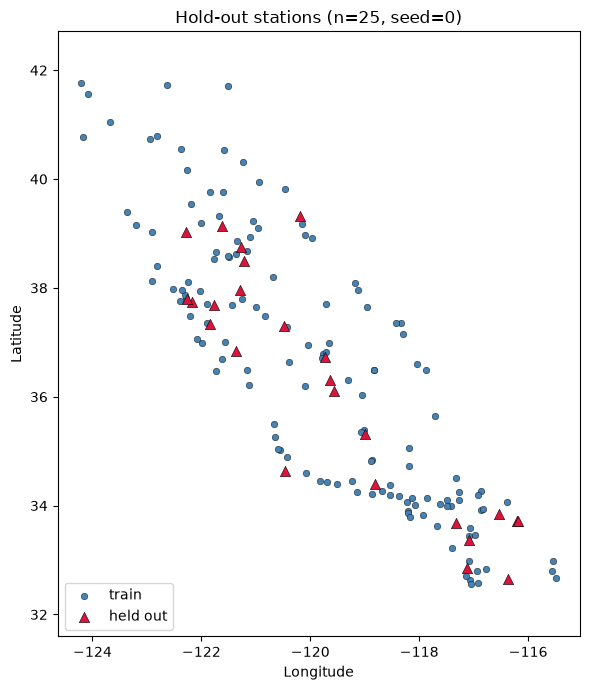

In [8]:
rng = np.random.default_rng(0)
test_idx = rng.choice(complete, size=25, replace=False)
train_mask = np.ones(len(values), dtype=bool)
train_mask[test_idx] = False

coords_train, values_train = coords[train_mask], values[train_mask]
coords_test, values_test = coords[test_idx], values[test_idx]
latlon_train = latlon.iloc[np.flatnonzero(train_mask)]
latlon_test = latlon.iloc[test_idx]

print(f"Train : {train_mask.sum()} stations, {int(np.isfinite(values_train).sum())} site-months")
print(f"Test  : {len(test_idx)} stations (held out), {int(np.isfinite(values_test).sum())} site-months")

fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(
    latlon_train["lon"], latlon_train["lat"],
    s=22, c="steelblue", edgecolor="k", linewidth=0.3, label="train",
)
ax.scatter(
    latlon_test["lon"], latlon_test["lat"],
    s=55, c="crimson", marker="^", edgecolor="k", linewidth=0.4, label="held out",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hold-out stations (n=25, seed=0)")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()



***
## 7. Fit ConvLSTM Regression Kriging

`ConvLSTM` (alias of `CNNLSTMRegressionKriging`) is fit on the **training stations only**. Hyperparameters match `tests/test_kriging_CNNLSTM.py`: `grid_size=32`, `hidden_channels=16`, `n_layers=2`, `max_epochs=300`, `patience=30`. A random 15% of training stations are held out internally for early stopping (`val_fraction=0.15`). Residual ordinary kriging uses a spherical variogram, independently per month.

`seed=` controls the (station, time) masking pattern, not PyTorch's global weight-init RNG, so exact numbers vary a little run to run — the same caveat as the graph-based sibling modules.


In [9]:
rk = ConvLSTM(
    grid_size=32,
    hidden_channels=16,
    n_layers=2,
    max_epochs=300,
    patience=30,
    device=DEVICE,
    seed=0,
)
rk.fit(coords_train, values_train, verbose=True)

print()
print(rk)
print(f"Raster used     : H={rk.H_}, W={rk.W_}  (grid_size={rk.grid_size})")
print(f"Epochs run      : {len(rk.train_losses_)}")
print(f"Best val loss   : {min(rk.val_losses_):.6f}")
print(f"Months with OK  : {sorted(rk.krige_by_step_)}")
print(f"CNNLSTM alias   : {isinstance(rk, CNNLSTMRegressionKriging)}")


Epoch 1/300 - Train Loss: 0.937790, Val Loss: 0.869771
Epoch 2/300 - Train Loss: 1.125548, Val Loss: 0.868404
Epoch 3/300 - Train Loss: 1.132708, Val Loss: 0.867160
Epoch 4/300 - Train Loss: 0.754675, Val Loss: 0.865671
Epoch 5/300 - Train Loss: 1.147377, Val Loss: 0.863968


Epoch 6/300 - Train Loss: 1.107541, Val Loss: 0.862026
Epoch 7/300 - Train Loss: 0.928407, Val Loss: 0.859520
Epoch 8/300 - Train Loss: 1.018404, Val Loss: 0.856397
Epoch 9/300 - Train Loss: 0.892542, Val Loss: 0.852163
Epoch 10/300 - Train Loss: 1.106255, Val Loss: 0.846894


Epoch 11/300 - Train Loss: 0.922399, Val Loss: 0.840281
Epoch 12/300 - Train Loss: 1.045048, Val Loss: 0.831928
Epoch 13/300 - Train Loss: 1.168269, Val Loss: 0.821775
Epoch 14/300 - Train Loss: 1.052638, Val Loss: 0.811198
Epoch 15/300 - Train Loss: 0.818484, Val Loss: 0.804339


Epoch 16/300 - Train Loss: 1.088233, Val Loss: 0.813819
Epoch 17/300 - Train Loss: 1.000622, Val Loss: 0.839296
Epoch 18/300 - Train Loss: 0.928514, Val Loss: 0.857238
Epoch 19/300 - Train Loss: 0.851029, Val Loss: 0.849365
Epoch 20/300 - Train Loss: 1.043478, Val Loss: 0.819620


Epoch 21/300 - Train Loss: 0.908130, Val Loss: 0.781711
Epoch 22/300 - Train Loss: 0.880434, Val Loss: 0.752359
Epoch 23/300 - Train Loss: 0.986665, Val Loss: 0.726748
Epoch 24/300 - Train Loss: 0.936916, Val Loss: 0.707171
Epoch 25/300 - Train Loss: 0.884509, Val Loss: 0.694136


...

Epoch 188/300 - Train Loss: 0.363194, Val Loss: 0.378625
Epoch 189/300 - Train Loss: 0.377588, Val Loss: 0.382315
Epoch 190/300 - Train Loss: 0.335174, Val Loss: 0.373118
Epoch 191/300 - Train Loss: 0.368292, Val Loss: 0.358066
Epoch 192/300 - Train Loss: 0.352917, Val Loss: 0.349174


Epoch 193/300 - Train Loss: 0.382097, Val Loss: 0.342801
Epoch 194/300 - Train Loss: 0.259883, Val Loss: 0.342181
Epoch 195/300 - Train Loss: 0.434229, Val Loss: 0.346148
Epoch 196/300 - Train Loss: 0.236119, Val Loss: 0.353272
Epoch 197/300 - Train Loss: 0.335755, Val Loss: 0.360344


Epoch 198/300 - Train Loss: 0.393277, Val Loss: 0.367859
Epoch 199/300 - Train Loss: 0.320620, Val Loss: 0.369395
Epoch 200/300 - Train Loss: 0.311530, Val Loss: 0.367789
Epoch 201/300 - Train Loss: 0.334348, Val Loss: 0.364302
Epoch 202/300 - Train Loss: 0.387578, Val Loss: 0.362087


Epoch 203/300 - Train Loss: 0.431308, Val Loss: 0.365662
Epoch 204/300 - Train Loss: 0.347255, Val Loss: 0.374129
Epoch 205/300 - Train Loss: 0.294195, Val Loss: 0.383661
Epoch 206/300 - Train Loss: 0.450108, Val Loss: 0.393200



ConvLSTM(grid_size=32, fitted)
Raster used     : H=32, W=24  (grid_size=32)
Epochs run      : 207
Best val loss   : 0.341740
Months with OK  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
CNNLSTM alias   : True



***
## 8. Training Curves

Validation loss is the early-stopping signal: a held-out fraction of *training* stations is fully excluded from the raster at every epoch, so the curve measures reconstruction at locations the ConvLSTM never saw as input.


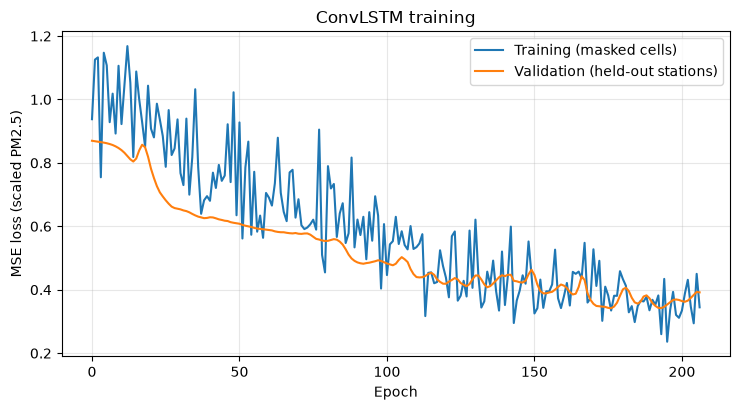

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(rk.train_losses_, label="Training (masked cells)")
ax.plot(rk.val_losses_, label="Validation (held-out stations)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (scaled PM2.5)")
ax.set_title("ConvLSTM training")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



***
## 9. Validate on Held-Out Stations

Predict every station-month of the 25 held-out stations from the trained ConvLSTM + residual kriging, and compare against a **naive baseline**: the overall training-mean PM2.5, which uses no spatial or temporal information. Classical space-time Ordinary Kriging on this exact split scores RMSE ≈ 2.24 µg/m³ ($R^2$ ≈ 0.58); ConvLSTM has come out as low as ~2.03 µg/m³ in development runs (matching TGCN almost exactly). Exact numbers move a little because weight initialization is not pinned.


In [11]:
pred_test, std_test = rk.predict(coords_test, return_std=True)
obs_mask_test = ~np.isnan(values_test)
y_obs = values_test[obs_mask_test]
y_hat = pred_test[obs_mask_test]
y_std = std_test[obs_mask_test]

rmse = float(np.sqrt(mean_squared_error(y_obs, y_hat)))
mae = float(mean_absolute_error(y_obs, y_hat))
r2 = float(r2_score(y_obs, y_hat))
me = float((y_obs - y_hat).mean())
train_mean = float(np.nanmean(values_train))
baseline_rmse = float(np.sqrt(mean_squared_error(y_obs, np.full_like(y_obs, train_mean))))

metrics = pd.DataFrame(
    {
        "RMSE": [rmse, baseline_rmse],
        "MAE": [mae, np.nan],
        "R2": [r2, np.nan],
        "ME": [me, np.nan],
        "RMSE / baseline": [rmse / baseline_rmse, 1.0],
    },
    index=["ConvLSTM RK", "Naive mean"],
)
print(
    f"ConvLSTM held-out-station RMSE={rmse:.3f} vs naive-mean baseline={baseline_rmse:.3f}"
)
print(f"Relative RMSE  : {rmse / baseline_rmse:.2f} × baseline")
print(f"Mean |SE|      : {y_std.mean():.3f} µg/m³  (residual-kriging SE)")
display(metrics.round(3))


ConvLSTM held-out-station RMSE=2.140 vs naive-mean baseline=3.461
Relative RMSE  : 0.62 × baseline
Mean |SE|      : 2.328 µg/m³  (residual-kriging SE)


,RMSE,MAE,R2,ME,RMSE / baseline
ConvLSTM RK,2.140,1.651,0.615,0.038,0.618
Naive mean,3.461,NaN,NaN,NaN,1.000


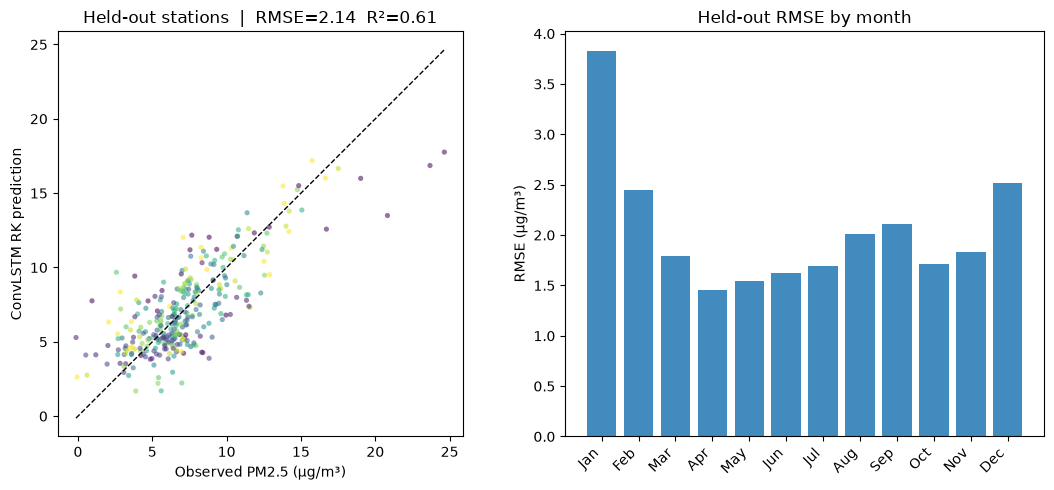

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lims = [min(y_obs.min(), y_hat.min()), max(y_obs.max(), y_hat.max())]
month_of = np.where(obs_mask_test)[1]
axes[0].scatter(
    y_obs, y_hat, s=14, alpha=0.55, c=month_of, cmap="viridis", edgecolor="none",
)
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Observed PM2.5 (µg/m³)")
axes[0].set_ylabel("ConvLSTM RK prediction")
axes[0].set_title(f"Held-out stations  |  RMSE={rmse:.2f}  R²={r2:.2f}")
axes[0].set_aspect("equal", adjustable="box")

rmse_by_month = []
for m in range(12):
    m_obs = values_test[:, m]
    m_hat = pred_test[:, m]
    keep = ~np.isnan(m_obs)
    rmse_by_month.append(float(np.sqrt(np.mean((m_obs[keep] - m_hat[keep]) ** 2))))
axes[1].bar(range(12), rmse_by_month, color="C0", alpha=0.85)
axes[1].set_xticks(range(12), MONTH_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("RMSE (µg/m³)")
axes[1].set_title("Held-out RMSE by month")
plt.tight_layout()
plt.show()


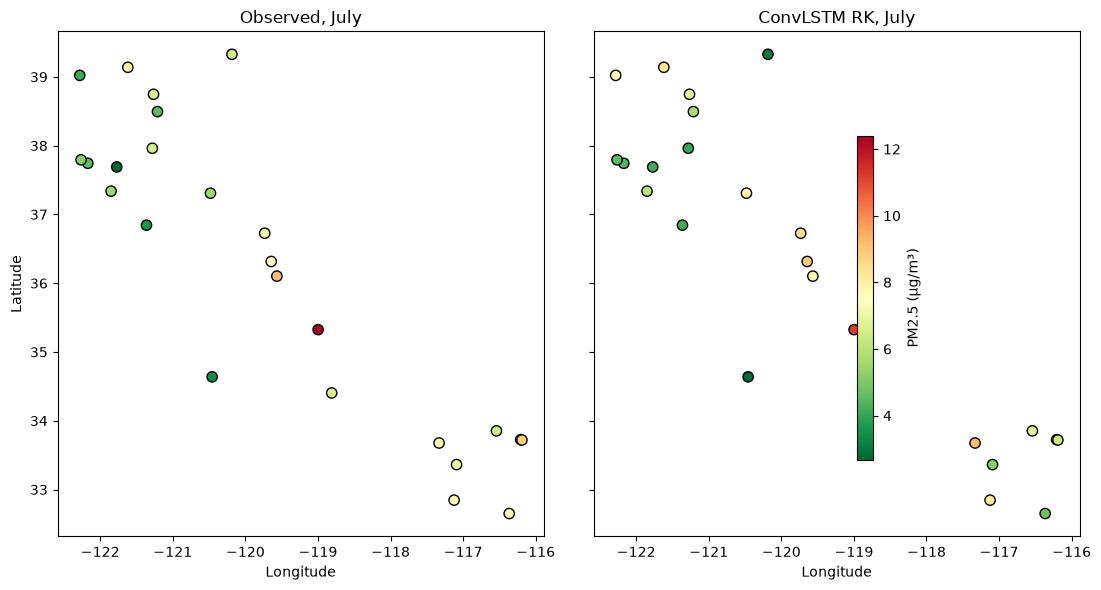

In [13]:
# July snapshot at the 25 held-out stations
snap_m = 6
vmin = np.nanmin([values_test[:, snap_m].min(), pred_test[:, snap_m].min()])
vmax = np.nanmax([values_test[:, snap_m].max(), pred_test[:, snap_m].max()])
fig, ax = plt.subplots(1, 2, figsize=(11, 6), sharex=True, sharey=True)
s0 = ax[0].scatter(
    latlon_test["lon"], latlon_test["lat"], c=values_test[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
ax[0].set_title("Observed, July")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
s1 = ax[1].scatter(
    latlon_test["lon"], latlon_test["lat"], c=pred_test[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
ax[1].set_title("ConvLSTM RK, July")
ax[1].set_xlabel("Longitude")
plt.colorbar(s1, ax=ax, label="PM2.5 (µg/m³)", shrink=0.7)
plt.tight_layout()
plt.show()



If RMSE is well below the naive-mean baseline, the raster ConvLSTM (plus residual kriging) is doing real work: nearby stations and nearby months are informing the prediction. Residual RMSE that varies by month usually tracks the seasonal amplitude of PM2.5 (winter is harder).



***
## 10. Residual Variograms

A spherical variogram is fit independently at each month on the ConvLSTM's out-of-fold residuals. A better trend typically leaves **less structured** residual spatial variation (smaller sill / shorter range). January (peak winter PM2.5) and July are shown.


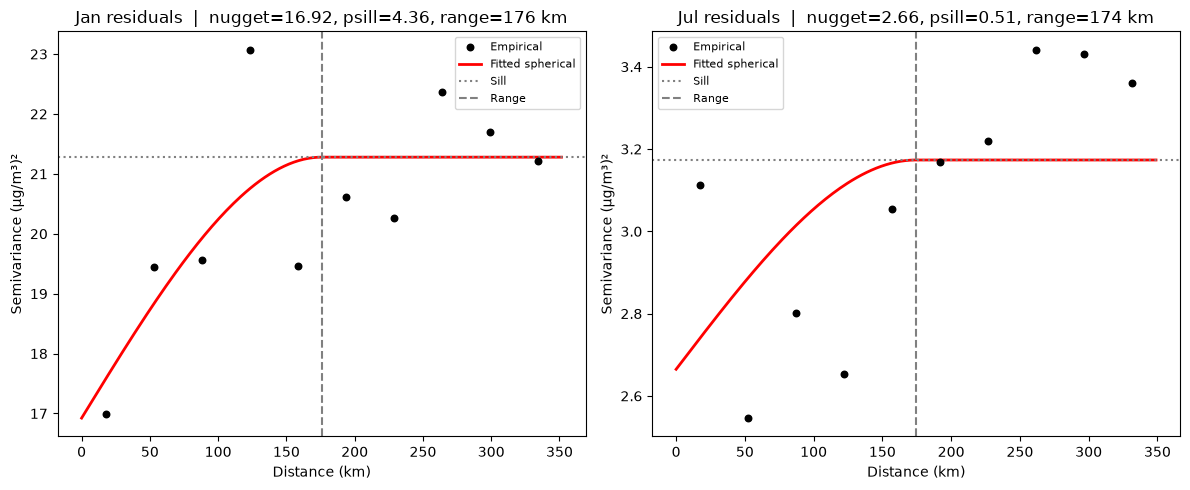

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, month in zip(axes, [0, 6]):
    krige = rk.krige_by_step_[month]
    vg_r = krige.variogram
    nugget, psill, rng_m = vg_r.fitted_params
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags / 1000, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine / 1000, vg_r(h_fine), color="red", linewidth=2, label="Fitted spherical")
    ax.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
    ax.axvline(rng_m / 1000, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Semivariance (µg/m³)²")
    ax.set_title(
        f"{MONTH_NAMES[month]} residuals  |  "
        f"nugget={nugget:.2f}, psill={psill:.2f}, range={rng_m/1000:.0f} km"
    )
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



***
## 11. Predict on the California Grid

For a production map we **refit `ConvLSTM` on the full 163-station panel** (rather than the train/test split), then predict at every cell of `data/CA_pm25_grid_predictions.csv` — the same 5 km California grid used by classical space-time Ordinary Kriging in Tutorial 13. `predict(..., return_std=True)` returns the residual-kriging standard error (not a ConvLSTM posterior).


In [15]:
grid = pd.read_csv(DATA_DIR / "CA_pm25_grid_predictions.csv")
grid_xy = grid.loc[grid["month"] == 0, ["x", "y"]].to_numpy()
print(f"Reference grid : {len(grid):,} rows  ({len(grid_xy):,} cells × 12 months)")
print(f"Columns        : {list(grid.columns)}")
print(f"Cell spacing   : ~{np.diff(np.sort(np.unique(grid_xy[:, 0]))).min():.0f} m")
grid.head()


Reference grid : 196,764 rows  (16,397 cells × 12 months)
Columns        : ['x', 'y', 'month', 'month_name', 'pm25_pred', 'pm25_sd']
Cell spacing   : ~5000 m


,x,y,month,month_name,pm25_pred,pm25_sd
0,273523.871,-602012.650,0,Jan,19.379,0.659
1,278523.871,-602012.650,0,Jan,21.009,0.306
2,283523.871,-602012.650,0,Jan,19.348,0.622
3,288523.871,-602012.650,0,Jan,18.211,0.571
4,273523.871,-597012.650,0,Jan,15.707,0.607


In [16]:
rk_full = ConvLSTM(
    grid_size=32,
    hidden_channels=16,
    n_layers=2,
    max_epochs=300,
    patience=30,
    device=DEVICE,
    seed=0,
)
rk_full.fit(coords, values, verbose=True)
pred_grid, std_grid = rk_full.predict(grid_xy, return_std=True)
print()
print(f"Grid prediction shape : {pred_grid.shape}")
print(f"Finite predictions     : {np.isfinite(pred_grid).all()}")
print(f"PM2.5 pred mean / max  : {pred_grid.mean():.2f} / {pred_grid.max():.2f} µg/m³")
print(f"SE mean / max          : {std_grid.mean():.2f} / {std_grid.max():.2f} µg/m³")


Epoch 1/300 - Train Loss: 1.014998, Val Loss: 1.061035
Epoch 2/300 - Train Loss: 0.980086, Val Loss: 1.059147
Epoch 3/300 - Train Loss: 1.013516, Val Loss: 1.057077
Epoch 4/300 - Train Loss: 0.877302, Val Loss: 1.054802


Epoch 5/300 - Train Loss: 1.073084, Val Loss: 1.052201


Epoch 6/300 - Train Loss: 1.110215, Val Loss: 1.049195
Epoch 7/300 - Train Loss: 0.891101, Val Loss: 1.045568
Epoch 8/300 - Train Loss: 0.964644, Val Loss: 1.041117
Epoch 9/300 - Train Loss: 0.812676, Val Loss: 1.035501


Epoch 10/300 - Train Loss: 1.155178, Val Loss: 1.028382


Epoch 11/300 - Train Loss: 1.072085, Val Loss: 1.019696
Epoch 12/300 - Train Loss: 0.936292, Val Loss: 1.008757
Epoch 13/300 - Train Loss: 0.981691, Val Loss: 0.996491
Epoch 14/300 - Train Loss: 1.072059, Val Loss: 0.986992


...

Epoch 159/300 - Train Loss: 0.339260, Val Loss: 0.503923


Epoch 160/300 - Train Loss: 0.447457, Val Loss: 0.508499
Epoch 161/300 - Train Loss: 0.410141, Val Loss: 0.519279
Epoch 162/300 - Train Loss: 0.349540, Val Loss: 0.524255
Epoch 163/300 - Train Loss: 0.399046, Val Loss: 0.526045


Epoch 164/300 - Train Loss: 0.344609, Val Loss: 0.516177


Epoch 165/300 - Train Loss: 0.308932, Val Loss: 0.510988
Epoch 166/300 - Train Loss: 0.426515, Val Loss: 0.524427



Grid prediction shape : (16397, 12)
Finite predictions     : True
PM2.5 pred mean / max  : 5.93 / 31.72 µg/m³
SE mean / max          : 2.34 / 4.73 µg/m³



***
## 12. Compare with Classical ST Kriging

The classical reference in `CA_pm25_grid_predictions.csv` is space-time Ordinary Kriging (`STKriging`, Tutorial 13). Per-month Pearson correlation between that surface and the ConvLSTM RK surface is the same check as `tests/test_kriging_CNNLSTM.py`. Graph-based models typically land around mean $r pprox 0.82$–$0.88$; ConvLSTM is usually a little lower (mean $r pprox 0.74$–$0.77$) because the sparse station network is rasterized onto a coarse image before the CNN ever sees it.


ConvLSTM vs classical STKriging reference: per-month corr = ['0.87', '0.81', '0.76', '0.69', '0.73', '0.80', '0.71', '0.71', '0.89', '0.67', '0.73', '0.77'], mean=0.762


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,mean
r_vs_STKriging,0.865,0.810,0.760,0.690,0.733,0.798,0.709,0.708,0.891,0.674,0.729,0.773,0.762


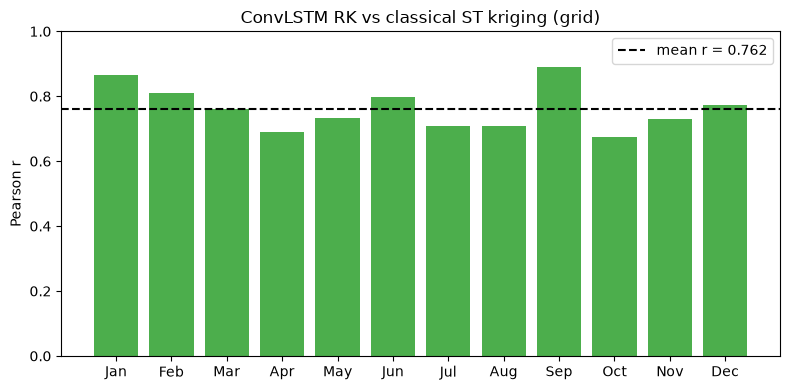

In [17]:
corrs = []
for month in range(12):
    ref = grid.loc[grid["month"] == month, "pm25_pred"].to_numpy()
    corrs.append(float(np.corrcoef(ref, pred_grid[:, month])[0, 1]))
mean_corr = float(np.mean(corrs))

corr_tbl = pd.DataFrame(
    {"month": MONTH_NAMES, "r_vs_STKriging": corrs}
).set_index("month")
corr_tbl.loc["mean"] = mean_corr
print(
    "ConvLSTM vs classical STKriging reference: per-month corr = "
    f"{[f'{c:.2f}' for c in corrs]}, mean={mean_corr:.3f}"
)
display(corr_tbl.T.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(12), corrs, color="C2", alpha=0.85)
ax.axhline(mean_corr, color="k", linestyle="--", label=f"mean r = {mean_corr:.3f}")
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.set_title("ConvLSTM RK vs classical ST kriging (grid)")
ax.legend()
plt.tight_layout()
plt.show()


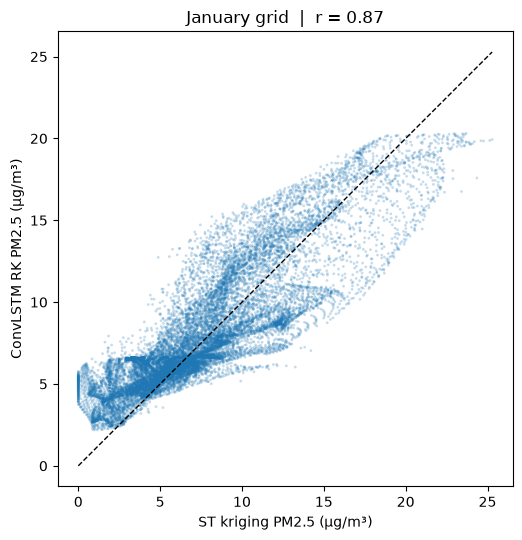

In [18]:
# January one-to-one: ConvLSTM vs classical ST kriging on the grid
ref_jan = grid.loc[grid["month"] == 0, "pm25_pred"].to_numpy()
hat_jan = pred_grid[:, 0]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(ref_jan, hat_jan, s=4, alpha=0.25, edgecolor="none")
lims = [
    min(ref_jan.min(), hat_jan.min()),
    max(ref_jan.max(), hat_jan.max()),
]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("ST kriging PM2.5 (µg/m³)")
ax.set_ylabel("ConvLSTM RK PM2.5 (µg/m³)")
ax.set_title(f"January grid  |  r = {corrs[0]:.2f}")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()



***
## 13. Map Predictions

Monthly ConvLSTM RK surfaces on the 5 km grid, clipped to California's boundary (`data/US_STATE.shp`, reprojected to EPSG:3310). Ordinary kriging of residuals has no positivity constraint, so a handful of cells far from stations can go slightly negative; they are clipped to 0 for display, matching Tutorial 13.


In [19]:
ca_states = gpd.read_file(DATA_DIR / "US_STATE.shp")
ca = ca_states[ca_states["STATE"] == "California"].to_crs("EPSG:3310")

n_clipped = int((pred_grid < 0).sum())
pred_map = np.clip(pred_grid, 0.0, None)
print(f"California boundary : {len(ca)} polygon feature(s), EPSG:3310")
print(f"Clipped negatives  : {n_clipped} / {pred_map.size} cells")

grid_pred = pd.concat(
    [
        pd.DataFrame(
            {
                "x": grid_xy[:, 0],
                "y": grid_xy[:, 1],
                "month": m,
                "month_name": MONTH_NAMES[m],
                "pm25_pred": pred_map[:, m],
                "pm25_sd": std_grid[:, m],
                "pm25_stk": grid.loc[grid["month"] == m, "pm25_pred"].to_numpy(),
            }
        )
        for m in range(12)
    ],
    ignore_index=True,
)
display(
    grid_pred.groupby("month_name")["pm25_pred"]
    .agg(["mean", "min", "max"])
    .loc[MONTH_NAMES]
)


California boundary : 1 polygon feature(s), EPSG:3310
Clipped negatives  : 520 / 196764 cells


,mean,min,max
month_name,,,
Jan,8.225,2.186,20.312
Feb,5.146,1.860,13.969
Mar,4.318,1.825,10.342
Apr,5.335,2.933,10.843
May,5.805,2.884,12.743
Jun,6.128,2.365,15.511
Jul,5.708,0.392,14.955
Aug,6.287,0.380,17.185
Sep,6.640,0.000,31.720


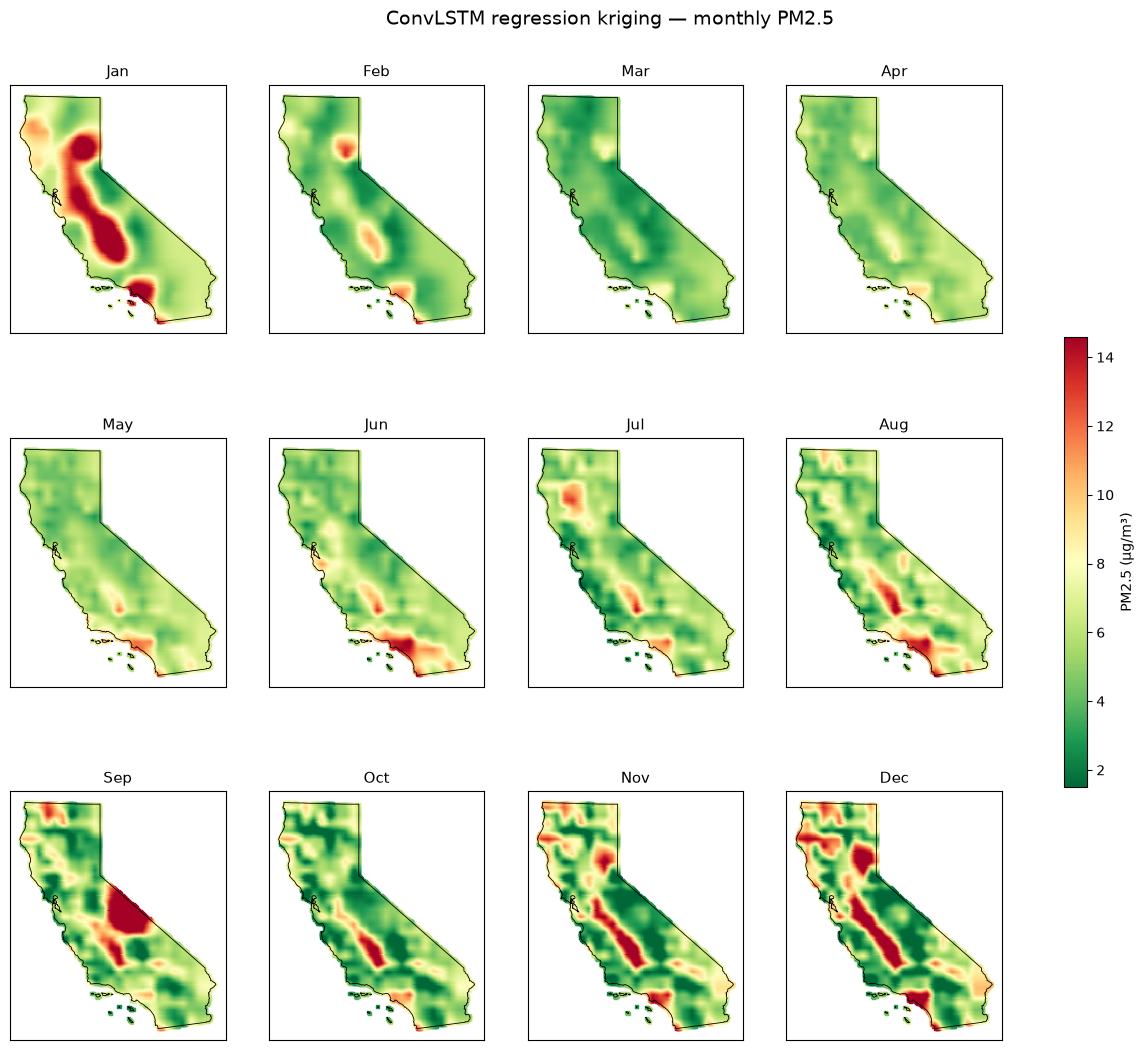

In [20]:
vmin, vmax = grid_pred["pm25_pred"].quantile(0.02), grid_pred["pm25_pred"].quantile(0.98)
fig, axes = plt.subplots(3, 4, figsize=(16, 13), sharex=True, sharey=True)
for m, ax in enumerate(axes.ravel()):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_pred"], cmap="RdYlGn_r",
        vmin=vmin, vmax=vmax, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(MONTH_NAMES[m], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.45, label="PM2.5 (µg/m³)")
fig.suptitle("ConvLSTM regression kriging — monthly PM2.5", fontsize=14, y=0.92)
plt.show()


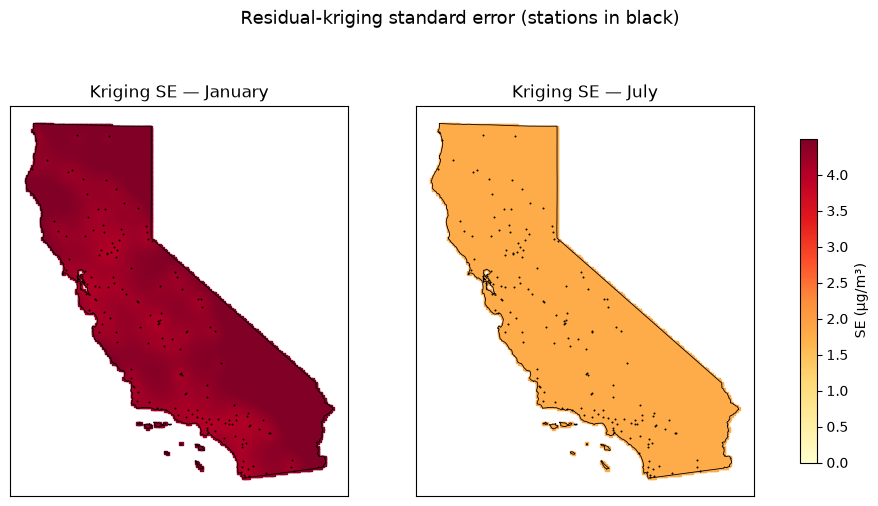

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sd_max = grid_pred["pm25_sd"].quantile(0.98)
for ax, m, title in zip(axes, [0, 6], ["January", "July"]):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_sd"], cmap="YlOrRd",
        vmin=0, vmax=sd_max, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.scatter(coords[:, 0], coords[:, 1], s=8, c="k", marker=".", linewidths=0)
    ax.set_title(f"Kriging SE — {title}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.7, label="SE (µg/m³)")
fig.suptitle("Residual-kriging standard error (stations in black)", fontsize=13, y=0.98)
plt.show()


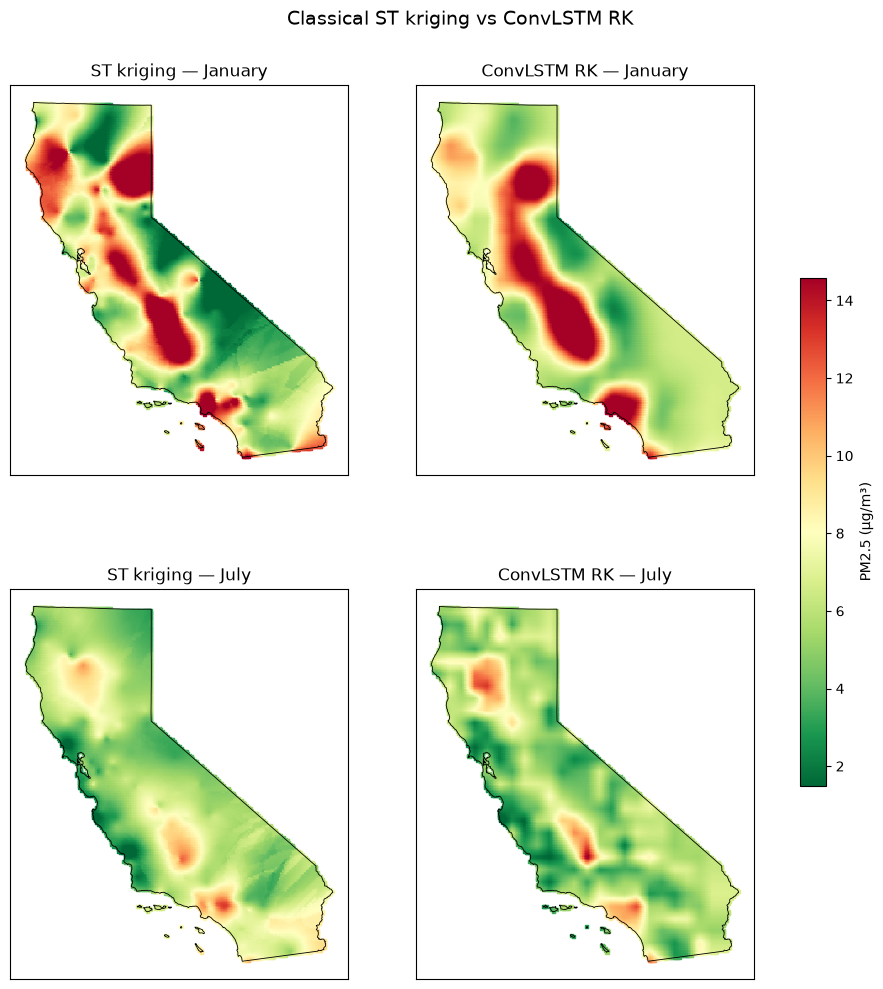

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
pairs = [
    (0, "pm25_stk", "ST kriging — January"),
    (0, "pm25_pred", "ConvLSTM RK — January"),
    (6, "pm25_stk", "ST kriging — July"),
    (6, "pm25_pred", "ConvLSTM RK — July"),
]
for ax, (m, col, title) in zip(axes.ravel(), pairs):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub[col], cmap="RdYlGn_r",
        vmin=vmin, vmax=vmax, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.55, label="PM2.5 (µg/m³)")
fig.suptitle("Classical ST kriging vs ConvLSTM RK", fontsize=14, y=0.93)
plt.show()



The monthly maps recover the well-known California pattern: winter peaks in the Central Valley, cleaner conditions along the coast, and a summer contrast driven by wildfire and photochemistry. The standard-error maps are high where stations are sparse (eastern deserts, far north) and low in the South Coast and Central Valley networks — a map of **how well the residual kriging is constrained**, not of ConvLSTM epistemic uncertainty. Side-by-side with classical ST kriging, ConvLSTM is smoother at coarse raster scale but tracks the same regional structure.


***
## 14. CPU vs GPU ConvLSTM Timing

The ~1,600-row CA station panel is too small for a GPU comparison: ConvLSTM
training cost is a small raster ConvLSTM, and host→device copies dominate.
Here we **simulate a CA-like monthly PM2.5 panel** with Sequential Gaussian
Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$
space-time observations, then time **`ConvLSTM.fit` + `predict`** on **CPU**
(`device='cpu'`) versus **GPU** (`device='cuda'`).

Simulation recipe (conditioned on the real 163 stations):

1. Draw $n_{\mathrm{sites}} = 700$ random locations in the California bounding box.
2. Simulate $\log(\mathrm{PM2.5})$ with `sgsim` (exponential variogram, practical range 250 km, conditioned on station-mean PM2.5 from `data/CA_pm25_2025.csv`) and back-transform with $\exp(\cdot)$.
3. Expand each site across 12 months using the observed statewide monthly relative seasonality, giving $n_{\mathrm{train}} = 8{,}400$ (700 stations × 12 months).
4. Draw a separate prediction set of $(x, y)$ locations (no values needed — the trend only needs coordinates plus the training panel).

The GPU work is **PyTorch training and the ConvLSTM forward pass**, not residual ordinary kriging. Residual OK is a dense CPU solve and would dominate at this $n$, so the timing section uses `krige_residuals=False`. Training size is held at 8{,}400 and we vary $n_{\mathrm{pred}}$. Epochs are capped at **5** so the comparison isolates device cost; the CA maps in §7 used `max_epochs=300`.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. `match` is **same-weights inference**: a GPU-trained network is copied to CPU and both devices must agree (`np.allclose`). Training itself is not bit-identical across devices. If CUDA cannot run here, the GPU column is skipped.


Simulating 700 CA-like PM2.5 sites with sgsim, then 12 months
  conditioning : 163 station means from data/CA_pm25_2025.csv
  vario        : azimuth=0, nugget=0.009, range=250 km, exponential, log(PM2.5)
  sgsim wall   : 5.1 s  (not included in ConvLSTM times)
  simulated PM2.5 : [1.07, 25.30] µg/m³  (CA observed [-0.50, 39.05])

GPU usable : True
Repeats    : 3  (median wall time of ConvLSTM fit + predict)
n_train    : 8400  (sgsim CA-like PM2.5 panel, 700 sites × 12 months)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the CA bbox)
settings   : architecture: grid_size=32, hidden_channels=16, 2 layers; max_epochs=5, krige_residuals=False

         dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
CA PM2.5 (sgsim)     8400     500     383.2     245.1   1.56×   True
CA PM2.5 (sgsim)     8400    1000     405.4     234.9   1.73×   True
CA PM2.5 (sgsim)     8400    2000     403.1     245.8   1.64×   True
CA PM2.5 (sgsim)     8400    4000     407.0     268.6   1

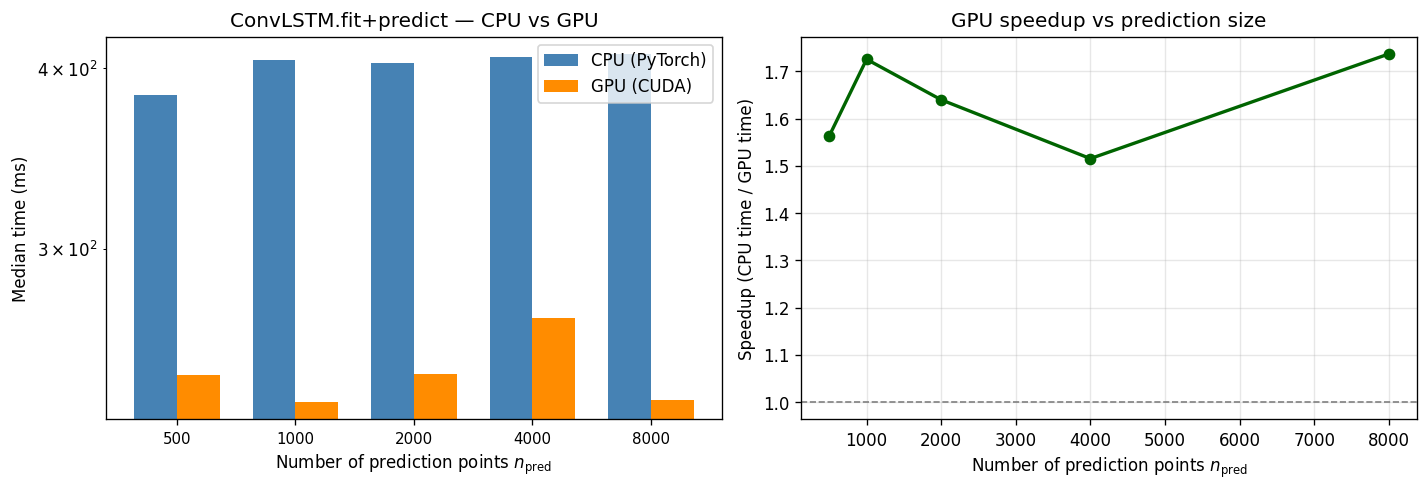

In [21]:
import time

N_REPEATS = 3
N_SITES = 700
N_MONTHS = 12
N_TRAIN = N_SITES * N_MONTHS
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
MAX_EPOCHS = 5
rng_sim = np.random.default_rng(42)

site = panel.groupby("site_id")[["x", "y", "pm25"]].mean().reset_index()
month_factor = panel.groupby("month")["pm25"].mean()
month_factor = (month_factor / month_factor.mean()).to_numpy()

pad = 15_000.0
xmin, xmax = float(panel["x"].min()) - pad, float(panel["x"].max()) + pad
ymin, ymax = float(panel["y"].min()) - pad, float(panel["y"].max()) + pad
xy_sites = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_SITES, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": site["x"].to_numpy(),
    "y": site["y"].to_numpy(),
    "log_pm25": np.log(np.maximum(site["pm25"].to_numpy(), 0.1)),
})
log_var = float(np.var(df_cond["log_pm25"]))
vario_sgs = [0, 0.05 * log_var, 250_000.0, 250_000.0, log_var, "exponential"]

print(f"Simulating {N_SITES:,} CA-like PM2.5 sites with sgsim, then {N_MONTHS} months")
print(f"  conditioning : {len(site)} station means from data/CA_pm25_2025.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=250 km, exponential, log(PM2.5)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_sites, df_cond, "x", "y", "log_pm25",
    num_points=12, vario=vario_sgs, radius=500_000.0,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
spatial = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in ConvLSTM times)")

values_train = spatial[:, None] * month_factor[None, :]
print(f"  simulated PM2.5 : [{values_train.min():.2f}, {values_train.max():.2f}] µg/m³"
      f"  (CA observed [{panel['pm25'].min():.2f}, {panel['pm25'].max():.2f}])")
print()

USE_CUDA = DEVICE == "cuda"


def _factory(device):
    return ConvLSTM(
        grid_size=32, hidden_channels=16, n_layers=2,
        max_epochs=MAX_EPOCHS, patience=20, device=device,
        krige_residuals=False, seed=0,
    )


def _sync(device):
    if device == "cuda":
        torch.cuda.synchronize()


def _time_fit_predict(xy, values, xy_pred, device, repeats=N_REPEATS, warmup=True):
    """Median wall time of ConvLSTM.fit + predict (trend only)."""
    def once():
        model = _factory(device)
        model.fit(xy, values, verbose=False)
        _sync(device)
        pred = model.predict(xy_pred)
        _sync(device)
        return model, pred

    if warmup:
        k = min(80, len(xy))
        k_pr = min(40, len(xy_pred))
        m = _factory(device)
        m.fit(xy[:k], values[:k], verbose=False)
        _sync(device)
        m.predict(xy_pred[:k_pr])
        _sync(device)

    times = []
    last_model, last_pred = None, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last_model, last_pred = once()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last_model, last_pred


def _inference_match(model, xy_pred, pred_gpu):
    model.model_.to("cpu")
    model.device_ = torch.device("cpu")
    if hasattr(model, "edge_index_") and model.edge_index_ is not None:
        model.edge_index_ = model.edge_index_.to("cpu")
    pred_cpu = model.predict(xy_pred)
    return bool(np.allclose(pred_gpu, pred_cpu, rtol=1e-3, atol=1e-4, equal_nan=True))


print(f"GPU usable : {USE_CUDA}")
print(f"Repeats    : {N_REPEATS}  (median wall time of ConvLSTM fit + predict)")
print(f"n_train    : {N_TRAIN}  (sgsim CA-like PM2.5 panel, {N_SITES} sites × {N_MONTHS} months)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the CA bbox)")
print(f"settings   : architecture: grid_size=32, hidden_channels=16, 2 layers; max_epochs=5, krige_residuals=False")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, _, _ = _time_fit_predict(xy_sites, values_train, xy_pr, "cpu")
    row = {
        "dataset": "CA PM2.5 (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_CUDA:
        gpu_t, gpu_model, pred_gpu = _time_fit_predict(
            xy_sites, values_train, xy_pr, "cuda",
        )
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = _inference_match(gpu_model, xy_pr, pred_gpu)
        torch.cuda.empty_cache()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (PyTorch)", color="steelblue")
if USE_CUDA and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CUDA)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("ConvLSTM.fit+predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_CUDA:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


`match = True` means the GPU-trained ConvLSTM, evaluated on CPU and on GPU with the **same weights**, agrees to `rtol=1e-3`. The GPU speedup comes from ConvLSTM training and the raster forward pass, not from SGS (simulation is CPU sequential and is excluded from the times) and not from residual ordinary kriging (turned off here). Because the raster size is fixed (`grid_size=32`), wall time is almost flat in $n_{\mathrm{pred}}$ — bilinear sampling of extra query points is cheap compared with the five training epochs. Use `device=DEVICE` so the same cells run on a laptop CPU or a CUDA workstation without edits. For the published CA maps, leave `krige_residuals=True` (the default).



***
## 15. Summary and Conclusions

This notebook applied **convolutional LSTM regression kriging** to California **monthly PM2.5**, the raster/CNN counterpart of the graph-based space-time models in `kriging_STGNN` and `kriging_STGTN`.

- **Data.** Daily readings at 163 stations (`CA_pm25_2025.csv`) aggregated to a monthly panel in EPSG:3310. The prediction grid is the classical ST-kriging surface in `CA_pm25_grid_predictions.csv`.
- **Trend.** Each month is rasterized onto a small regular image (`grid_size=32`, aspect-preserving). A ConvLSTM (Shi et al., 2015) processes the image sequence with 2-D convolutions in every LSTM gate. Predictions at arbitrary coordinates are bilinear samples of the output image — not nearest-pixel snaps.
- **Training.** IGNNK-style random masking of (station, month) cells, plus a validation subset of stations always fully excluded, so the network interpolates to locations it never saw as input.
- **Residuals.** Out-of-fold ConvLSTM reconstructions are kriged spatially, independently per month, and added back (`OrdinaryKriging` of a spherical variogram).
- **Validation.** The same 25 complete held-out stations as Tutorial 13 / `tests/test_kriging_CNNLSTM.py`. ConvLSTM RK should beat a naive-mean baseline by a comfortable margin and land near classical ST kriging (RMSE ≈ 2.2 µg/m³) and TGCN.
- **Grid.** Per-month correlation with the classical ST-kriging reference is typically $r \approx 0.6$–$0.9$ (mean ~0.74–0.77) — a real cost of rasterizing a sparse network, not a bug.

### CPU vs GPU

Timed `ConvLSTM.fit` + `predict` on CPU vs GPU using an SGS-simulated CA-like panel ($n_{\mathrm{train}}=8{,}400$), with residual kriging off so the times isolate the neural net.

- **CPU / GPU.** `ConvLSTM(..., device=DEVICE)` trains a raster ConvLSTM on PyTorch. GPU work is the network, not residual OK. The 163-station CA panel is too small to show that; §14 uses SGS so $n > 5{,}000$, `krige_residuals=False`, and a short epoch budget.

### When to use ConvLSTM RK

- You have a **monitoring network through time** (fixed sites, repeated measurements) and want a learned spatio-temporal trend plus kriged residuals.
- You prefer a **CNN inductive bias** (local, translationally invariant filters on a regular grid) over a $k$-NN graph.
- You do **not** have dense covariates at every prediction cell (this module's trend is the rasterized panel itself, not external regressors — unlike tutorials 7.1–7.5).

### When not to use it

- A purely spatial snapshot with no time dimension — use ordinary, universal, or regression kriging (tutorials 4–7).
- Count / rate data over polygons — use Poisson kriging.
- You need the exact station topology preserved and can afford a graph model — `TGCN` / `DCRNN` / `STTN` / `GMAN` typically correlate more tightly with classical ST kriging on this panel.

### Objects used here

| Object | Role |
|--------|------|
| `pygstat.ConvLSTM` | ConvLSTM trend + per-month residual ordinary kriging (alias of `CNNLSTMRegressionKriging`) |
| `pygstat.CNNLSTMRegressionKriging` | Same class under the generic engine name |
| `pygstat.load_ca_pm25_panel` | Daily CA PM2.5 CSV → monthly panel in EPSG:3310 |
| `fit(..., val_fraction=)` | Internal early-stopping split; validation stations are fully excluded from the raster |
| `predict(..., return_std=True)` | RK prediction plus residual kriging standard error |
| `train_losses_`, `val_losses_`, `krige_by_step_` | Training curves and per-month `OrdinaryKriging` residual models |
| `H_`, `W_` | Fitted raster shape (aspect-preserving) |

Install extras with `pip install pygstat[pytorch]`. Set `device='cuda'` to force a GPU, or leave `device='auto'` (used here via `DEVICE`) to fall back to CPU when CUDA is unavailable. Related tutorials: [13 Spatio-Temporal Kriging](13_krigingST.ipynb), [6.5 GNN RK](06_05_regression_kriging_gnn.ipynb), [6.3 PyTorch MLP RK](06_03_regression_kriging_pytorch.ipynb).



***
## 16. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Shi, X., Chen, Z., Wang, H., Yeung, D.-Y., Wong, W.-K. & Woo, W.-C. (2015). Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting. *NeurIPS*. [arXiv:1506.04214](https://arxiv.org/abs/1506.04214) | ConvLSTM cell used here |
| Wu, Y., Cui, X., Nie, X. & Wang, H. (2021). Inductive Graph Neural Networks for Spatiotemporal Kriging. *AAAI*. | Masked-reconstruction training (IGNNK) |
| Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8). | LSTM gates that ConvLSTM convolves |
| LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proc. IEEE*. | CNN inductive bias |
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | Residual kriging |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences*, 33(10). | RK recipe |
| Pebesma, E. (2012). spacetime: Spatio-Temporal Data in R. *Journal of Statistical Software*, 51(7). | Classical ST kriging reference (`STKriging`) |

### In this library

| Object | Role |
|--------|------|
| `pygstat.ConvLSTM` / `CNNLSTMRegressionKriging` | This tutorial |
| `pygstat.TGCN`, `DCRNN` | Recurrent GNN regression kriging |
| `pygstat.STTN`, `GMAN` | Graph Transformer regression kriging |
| `pygstat.STKriging` | Classical space-time ordinary kriging (Tutorial 13) |
| `pygstat.GNNRegressionKriging`, `KCN`, `IGNNK` | Spatial (no time) GNN RK (Tutorial 7.5) |
| `pygstat.sgsim` | Sequential Gaussian Simulation (used in §14 to build $n>5{,}000$ training data) |
| `tests/test_kriging_CNNLSTM.py` | Unit tests this notebook follows |
| `scripts/predict_ca_pm25_grid.py` | Builds `CA_pm25_grid_predictions.csv` |
